In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import DataSet
from google.colab import files
uploaded = files.upload()

Saving traffic.csv to traffic.csv


In [3]:
#Load Data
df = pd.read_csv('traffic.csv')
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
#Understand Data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [5]:
df = df.dropna()  # missing values remove

In [8]:
print(df.columns)

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')


In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
sessions = len(df)
print("Total Sessions:", sessions)

Total Sessions: 219149


In [14]:
users = df['linkid'].nunique()
print("Total Users:", users)

Total Users: 743


In [15]:
df['country'].value_counts().head()

,count
country,
Saudi Arabia,46960
India,42991
United States,27355
France,15638
Iraq,8168


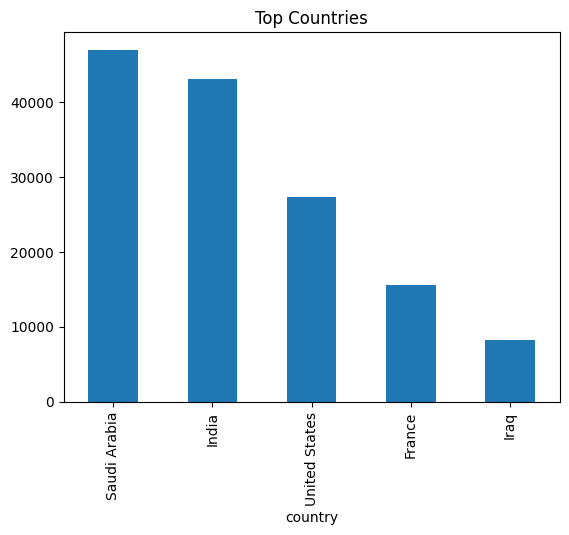

In [16]:
df['country'].value_counts().head(5).plot(kind='bar')
plt.title("Top Countries")
plt.show()

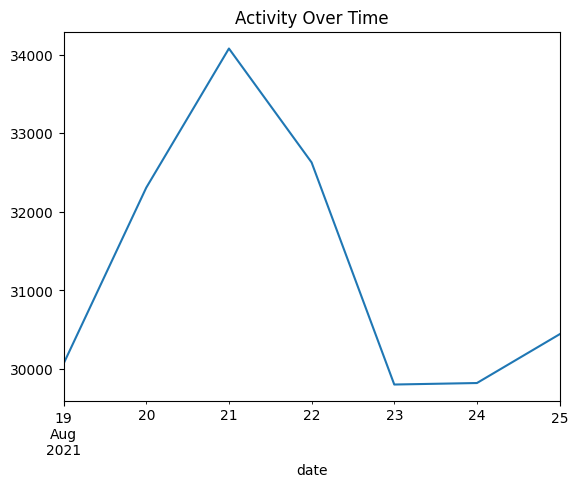

In [17]:
df.groupby('date').size().plot()
plt.title("Activity Over Time")
plt.show()

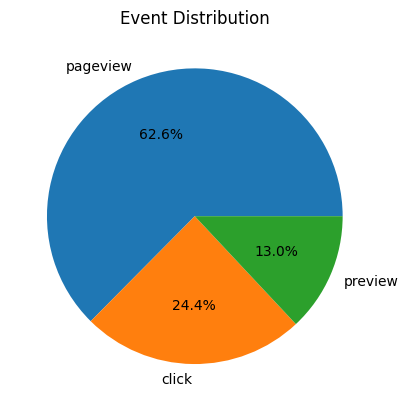

In [18]:
df['event'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Event Distribution")
plt.ylabel("")
plt.show()

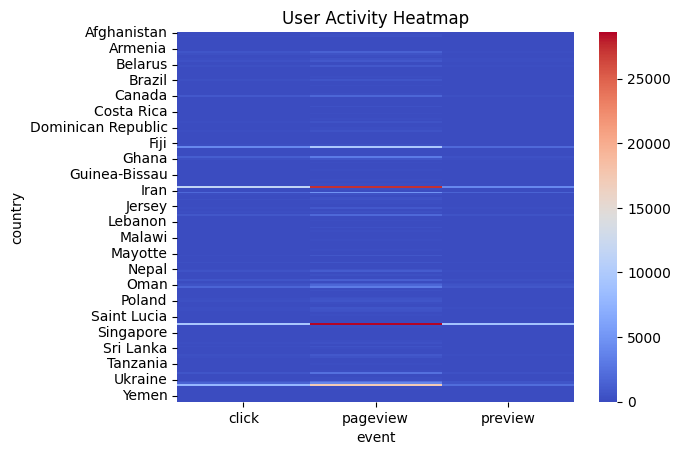

In [20]:
pivot = df.pivot_table(index='country', columns='event', aggfunc='size', fill_value=0)

sns.heatmap(pivot, cmap='coolwarm')
plt.title("User Activity Heatmap")
plt.show()